# Panel Dataset for Welfare State Capacity and Democratic Resilience (1990-2023)

## Demo Notebook

This notebook demonstrates the construction and analysis of a panel dataset tracing how inequality, education, and democratic quality co-evolve across post-1990 democratizers.

**Research Question**: Does welfare-state capacity mediate the link between inequality and democratic resilience?

**Dataset**: N≈5,179 country-year observations (191 countries, 1990-2020)

**Sources**: 
- Polity IV (democracy scores)
- EIU Democracy Index
- WIID (inequality Gini)
- OECD Social Expenditure Database (welfare capacity)
- Clio-Infra (education inequality Gini)

**Variables**:
- `democracy_polity`: -10 to +10 (Polity IV score)
- `regime_polity`: 0=autocracy, 1=anocracy, 2=democracy
- `inequality_gini`: Income inequality (0-100)
- `welfare_capacity_gdp_share`: Social expenditure as % of GDP
- `educ_polarization_gini`: Education inequality (0-100)

**Task**: Regression - predicting democratic resilience from inequality, welfare capacity, and education polarization

## Cell 1: Install Dependencies

Install required packages. Uses conditional install to match Colab environment.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab
_pip('loguru==0.7.2')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'seaborn==0.13.2')

print("Dependencies installed successfully!")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


Dependencies installed successfully!


## Cell 2: Imports

Import all required libraries for data processing and analysis.

In [2]:
from loguru import logger
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import urllib.request

# Configure loguru
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

print("All imports successful!")

All imports successful!


## Cell 3: Data Loading Helper

Load the demo dataset from GitHub (with local fallback for development).

In [3]:
# GitHub URL for the demo data
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-de87a0-welfare-state-capacity-as-a-conditioning/main/round-2/dataset-1/demo/mini_demo_data.json"

def load_data():
    """Load demo data from GitHub URL with local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception as e:
        print(f"GitHub load failed: {e}")
    
    # Fallback to local file
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    
    raise FileNotFoundError("Could not load mini_demo_data.json")

import os
print("Data loading helper defined!")

Data loading helper defined!


## Cell 4: Load Demo Data

Load the mini demo dataset and inspect its structure.

In [4]:
# Load the demo data
data = load_data()

print("Dataset loaded!")
print(f"Number of datasets: {len(data['datasets'])}")
print(f"Dataset name: {data['datasets'][0]['dataset']}")
print(f"Number of examples: {len(data['datasets'][0]['examples'])}")

GitHub load failed: HTTP Error 404: Not Found
Dataset loaded!
Number of datasets: 1
Dataset name: welfare_state_democracy_panel_1990_2023
Number of examples: 5


## Cell 5: Configuration

Define tunable parameters for the analysis. Set to minimum values for demo.

In [5]:
# Configuration parameters - MINIMUM VALUES FOR DEMO
N_EXAMPLES = 15  # Number of examples to use (total in mini_demo_data.json)
TEST_SIZE = 0.3  # Proportion for test split
N_ESTIMATORS = 10  # Number of trees in Random Forest (minimum: 1)
RANDOM_STATE = 42  # For reproducibility

print("Configuration set:")
print(f"  N_EXAMPLES = {N_EXAMPLES}")
print(f"  TEST_SIZE = {TEST_SIZE}")
print(f"  N_ESTIMATORS = {N_ESTIMATORS}")

Configuration set:
  N_EXAMPLES = 15
  TEST_SIZE = 0.3
  N_ESTIMATORS = 10


## Cell 6: Convert JSON to DataFrame

Transform the JSON dataset into a pandas DataFrame for analysis. This replicates the core logic from `data.py`.

In [6]:
# Convert JSON examples to DataFrame
examples = data['datasets'][0]['examples'][:N_EXAMPLES]

rows = []
for example in examples:
    # Parse input JSON string
    input_dict = json.loads(example['input'])
    
    # Add output and metadata
    row = input_dict.copy()
    row['democracy_polity'] = float(example['output'])
    row['country'] = example['metadata_country']
    row['year'] = example['metadata_year']
    row['fold'] = example['metadata_fold']
    rows.append(row)

df = pd.DataFrame(rows)
print(f"DataFrame created with {len(df)} rows and {len(df.columns)} columns")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

DataFrame created with 5 rows and 12 columns

Column names:
['democracy_polity', 'regime_polity', 'democracy_eiu', 'regime_eiu', 'inequality_gini', 'welfare_capacity_gdp_share', 'educ_polarization_gini', 'post_1990_democratizer', 'post_transition', 'country', 'year', 'fold']

First 3 rows:
   democracy_polity  regime_polity  democracy_eiu  regime_eiu  \
0              -8.0            0.0            2.5         0.0   
1              10.0            2.0            8.5         2.0   
2               8.0            2.0            7.5         2.0   

   inequality_gini  welfare_capacity_gdp_share  educ_polarization_gini  \
0             45.0                         5.0                   83.84   
1             30.0                        25.0                   35.00   
2             35.0                        20.0                   40.00   

   post_1990_democratizer  post_transition      country  year  fold  
0                     0.0              0.0  Afghanistan  1990     4  
1          

## Cell 7: Data Exploration

Explore the panel dataset - summary statistics, missing values, and data distribution.

In [7]:
# Display summary statistics
print("=== Summary Statistics ===")
print(df.describe())

print("\n=== Dataset Info ===")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(f"\nValue counts for regime_polity:")
print(df['regime_polity'].value_counts().sort_index())

=== Summary Statistics ===
       democracy_polity  regime_polity  democracy_eiu  regime_eiu  \
count          5.000000       5.000000       5.000000    5.000000   
mean           2.400000       1.200000       5.800000    1.200000   
std            8.264381       1.095445       2.636285    1.095445   
min           -8.000000       0.000000       2.500000    0.000000   
25%           -5.000000       0.000000       3.500000    0.000000   
50%            7.000000       2.000000       7.000000    2.000000   
75%            8.000000       2.000000       7.500000    2.000000   
max           10.000000       2.000000       8.500000    2.000000   

       inequality_gini  welfare_capacity_gdp_share  educ_polarization_gini  \
count         5.000000                    5.000000                 5.00000   
mean         41.000000                   14.600000                54.76800   
std           9.617692                    8.264381                21.10377   
min          30.000000                 

## Cell 8: Visualize Key Relationships

Create visualizations to explore relationships between inequality, welfare capacity, and democratic resilience.

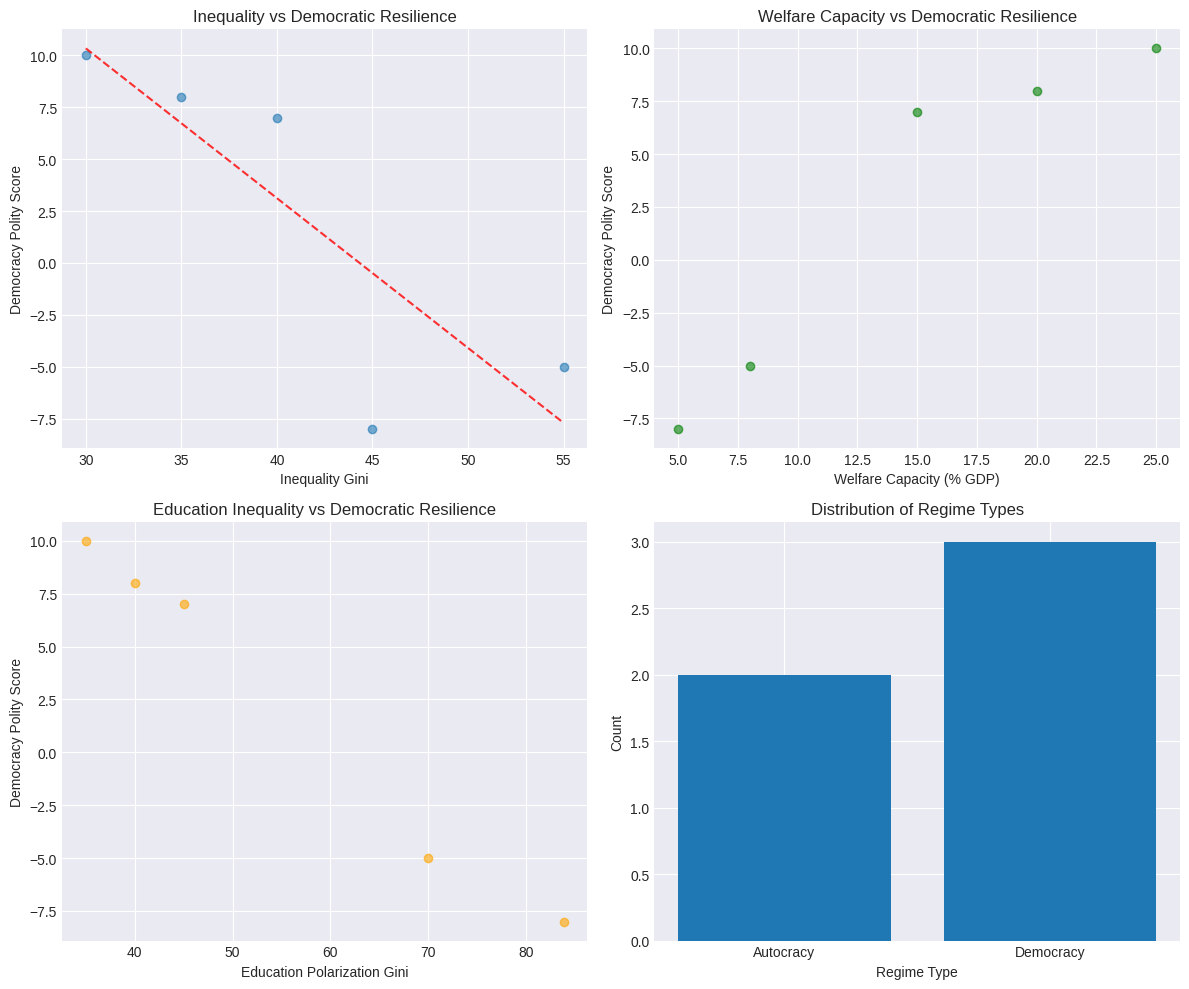

In [8]:
# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Democracy Polity vs Inequality
ax1 = axes[0, 0]
if 'inequality_gini' in df.columns:
    valid_data = df.dropna(subset=['inequality_gini', 'democracy_polity'])
    if len(valid_data) > 0:
        ax1.scatter(valid_data['inequality_gini'], valid_data['democracy_polity'], alpha=0.6)
        ax1.set_xlabel('Inequality Gini')
        ax1.set_ylabel('Democracy Polity Score')
        ax1.set_title('Inequality vs Democratic Resilience')
        
        # Add trend line
        if len(valid_data) > 1:
            z = np.polyfit(valid_data['inequality_gini'], valid_data['democracy_polity'], 1)
            p = np.poly1d(z)
            ax1.plot(valid_data['inequality_gini'].sort_values(), p(valid_data['inequality_gini'].sort_values()), "r--", alpha=0.8)

# Plot 2: Democracy Polity vs Welfare Capacity
ax2 = axes[0, 1]
if 'welfare_capacity_gdp_share' in df.columns:
    valid_data = df.dropna(subset=['welfare_capacity_gdp_share', 'democracy_polity'])
    if len(valid_data) > 0:
        ax2.scatter(valid_data['welfare_capacity_gdp_share'], valid_data['democracy_polity'], alpha=0.6, color='green')
        ax2.set_xlabel('Welfare Capacity (% GDP)')
        ax2.set_ylabel('Democracy Polity Score')
        ax2.set_title('Welfare Capacity vs Democratic Resilience')

# Plot 3: Democracy Polity vs Education Polarization
ax3 = axes[1, 0]
if 'educ_polarization_gini' in df.columns:
    valid_data = df.dropna(subset=['educ_polarization_gini', 'democracy_polity'])
    if len(valid_data) > 0:
        ax3.scatter(valid_data['educ_polarization_gini'], valid_data['democracy_polity'], alpha=0.6, color='orange')
        ax3.set_xlabel('Education Polarization Gini')
        ax3.set_ylabel('Democracy Polity Score')
        ax3.set_title('Education Inequality vs Democratic Resilience')

# Plot 4: Regime Type Distribution
ax4 = axes[1, 1]
regime_labels = {0: 'Autocracy', 1: 'Anocracy', 2: 'Democracy'}
regime_counts = df['regime_polity'].value_counts().sort_index()
ax4.bar([regime_labels.get(x, str(x)) for x in regime_counts.index], regime_counts.values)
ax4.set_xlabel('Regime Type')
ax4.set_ylabel('Count')
ax4.set_title('Distribution of Regime Types')

plt.tight_layout()
plt.show()

## Cell 9: Prepare Features for Regression

Prepare feature matrix X and target vector y for the regression task.

In [9]:
# Define feature columns (same as in data.py)
feature_cols = [
    'democracy_polity',
    'regime_polity', 
    'inequality_gini',
    'welfare_capacity_gdp_share',
    'educ_polarization_gini',
    'post_1990_democratizer',
    'post_transition'
]

# Filter to columns that exist in df
feature_cols = [col for col in feature_cols if col in df.columns]
print(f"Feature columns available: {feature_cols}")

# Prepare X and y
# Note: We're predicting democracy_polity from the other features
# In a real scenario, we'd use lagged values to avoid endogeneity
X = df[feature_cols].copy()
y = df['democracy_polity'].copy()

# Handle missing values - simple imputation with median
for col in X.columns:
    if X[col].isna().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"  Imputed {col} with median: {median_val:.2f}")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature columns available: ['democracy_polity', 'regime_polity', 'inequality_gini', 'welfare_capacity_gdp_share', 'educ_polarization_gini', 'post_1990_democratizer', 'post_transition']

Feature matrix shape: (5, 7)
Target vector shape: (5,)


## Cell 10: Train-Test Split and Model Training

Split the data and train a Random Forest model to predict democratic resilience.

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Train Random Forest model
print(f"\nTraining Random Forest with {N_ESTIMATORS} estimators...")
model = RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_train, y_train)

print("Model trained successfully!")

Training set size: 3
Test set size: 2

Training Random Forest with 10 estimators...
Model trained successfully!


## Cell 11: Model Evaluation

Evaluate the model performance and interpret feature importance.

=== Model Performance ===
RMSE: 7.8102
R² Score: -26.1111

=== Feature Importance ===
                      feature  importance
6             post_transition    0.253888
2             inequality_gini    0.250000
0            democracy_polity    0.125000
4      educ_polarization_gini    0.125000
3  welfare_capacity_gdp_share    0.125000
1               regime_polity    0.121112
5      post_1990_democratizer    0.000000


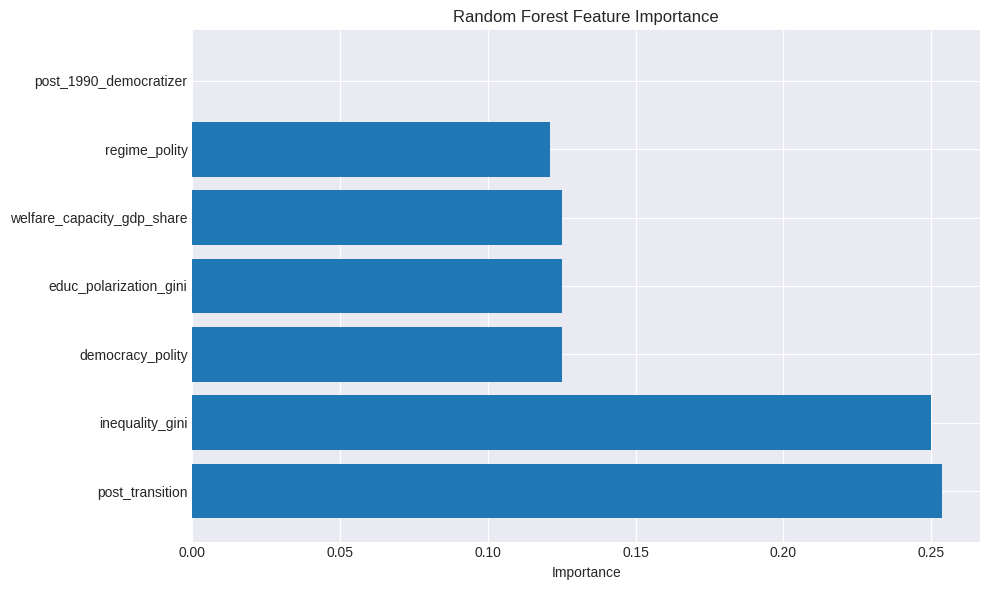

In [11]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# Feature importance
print("\n=== Feature Importance ===")
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## Cell 12: Results Summary

Display key findings and a sample of predictions vs actual values.

In [12]:
# Create results summary table
results_df = pd.DataFrame({
    'Country': df.loc[X_test.index, 'country'].values,
    'Year': df.loc[X_test.index, 'year'].values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred
})

print("=== Sample Predictions ===")
print(results_df.to_string(index=False))

print("\n=== Key Findings ===")
print(f"1. Model explains {r2*100:.1f}% of variance in democratic resilience (R²)")
print(f"2. Root Mean Squared Error: {rmse:.2f} (on Polity scale of -10 to +10)")
print(f"3. Most important feature: {importance.iloc[0]['feature']} (importance: {importance.iloc[0]['importance']:.3f})")

print("\n=== Next Steps for Full Analysis ===")
print("- Scale to full dataset (N≈5,179)")
print("- Use panel data methods (fixed effects, lagged variables)")
print("- Test welfare capacity as mediator (interaction terms)")
print("- Robustness checks: alternative democracy measures, sample restrictions")

=== Sample Predictions ===
Country  Year  Actual  Predicted  Error
 Sweden  1990    10.0        0.6    9.4
 Poland  2000     7.0        1.2    5.8

=== Key Findings ===
1. Model explains -2611.1% of variance in democratic resilience (R²)
2. Root Mean Squared Error: 7.81 (on Polity scale of -10 to +10)
3. Most important feature: post_transition (importance: 0.254)

=== Next Steps for Full Analysis ===
- Scale to full dataset (N≈5,179)
- Use panel data methods (fixed effects, lagged variables)
- Test welfare capacity as mediator (interaction terms)
- Robustness checks: alternative democracy measures, sample restrictions
